In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving QVI_data.csv to QVI_data.csv


In [ ]:
data = pd.read_csv("QVI_data.csv")

In [ ]:
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [ ]:
data.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [ ]:
data.isnull().sum()

,0
LYLTY_CARD_NBR,0
DATE,0
STORE_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


In [ ]:
data['DATE'] = pd.to_datetime(data['DATE'])

In [ ]:
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [ ]:
data['YEAR_MONTH'] = data['DATE'].dt.to_period('M')

In [ ]:
monthly_sales = data.groupby(
    ['STORE_NBR','YEAR_MONTH']
)['TOT_SALES'].sum().reset_index()

monthly_sales.head()

,STORE_NBR,YEAR_MONTH,TOT_SALES
0,1,2018-07,206.9
1,1,2018-08,176.1
2,1,2018-09,278.8
3,1,2018-10,188.1
4,1,2018-11,192.6


In [ ]:
monthly_customers = data.groupby(
    ['STORE_NBR','YEAR_MONTH']
)['LYLTY_CARD_NBR'].nunique().reset_index()

monthly_customers.rename(
    columns={'LYLTY_CARD_NBR':'CUSTOMERS'},
    inplace=True
)

monthly_customers.head()

,STORE_NBR,YEAR_MONTH,CUSTOMERS
0,1,2018-07,49
1,1,2018-08,42
2,1,2018-09,59
3,1,2018-10,44
4,1,2018-11,46


In [ ]:
monthly_transactions = data.groupby(
    ['STORE_NBR','YEAR_MONTH']
)['TXN_ID'].count().reset_index()

monthly_transactions.rename(
    columns={'TXN_ID':'TRANSACTIONS'},
    inplace=True
)

monthly_transactions.head()

,STORE_NBR,YEAR_MONTH,TRANSACTIONS
0,1,2018-07,52
1,1,2018-08,43
2,1,2018-09,62
3,1,2018-10,45
4,1,2018-11,47


In [ ]:
monthly_metrics = monthly_transactions.merge(
    monthly_customers,
    on=['STORE_NBR','YEAR_MONTH']
)

monthly_metrics['AVG_TXN_PER_CUSTOMER'] = (
    monthly_metrics['TRANSACTIONS']
    / monthly_metrics['CUSTOMERS']
)

monthly_metrics.head()

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER
0,1,2018-07,52,49,1.061224
1,1,2018-08,43,42,1.023810
2,1,2018-09,62,59,1.050847
3,1,2018-10,45,44,1.022727
4,1,2018-11,47,46,1.021739


In [ ]:
monthly_metrics = monthly_metrics.merge(
    monthly_sales,
    on=['STORE_NBR', 'YEAR_MONTH']
)

monthly_metrics.head()

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER,TOT_SALES
0,1,2018-07,52,49,1.061224,206.9
1,1,2018-08,43,42,1.023810,176.1
2,1,2018-09,62,59,1.050847,278.8
3,1,2018-10,45,44,1.022727,188.1
4,1,2018-11,47,46,1.021739,192.6


In [ ]:
monthly_metrics['YEAR_MONTH'] = monthly_metrics['YEAR_MONTH'].astype(str)

monthly_metrics.head()

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER,TOT_SALES
0,1,2018-07,52,49,1.061224,206.9
1,1,2018-08,43,42,1.023810,176.1
2,1,2018-09,62,59,1.050847,278.8
3,1,2018-10,45,44,1.022727,188.1
4,1,2018-11,47,46,1.021739,192.6


In [ ]:
pre_trial = monthly_metrics[
    (monthly_metrics['YEAR_MONTH'] >= '2018-07') &
    (monthly_metrics['YEAR_MONTH'] <= '2019-01')
]

pre_trial.head()

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER,TOT_SALES
0,1,2018-07,52,49,1.061224,206.9
1,1,2018-08,43,42,1.023810,176.1
2,1,2018-09,62,59,1.050847,278.8
3,1,2018-10,45,44,1.022727,188.1
4,1,2018-11,47,46,1.021739,192.6


In [ ]:
from scipy.stats import pearsonr

In [ ]:
def find_control_store(trial_store):

    trial = pre_trial[
        pre_trial['STORE_NBR'] == trial_store
    ].sort_values('YEAR_MONTH')

    correlations = []

    for store in pre_trial['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control = pre_trial[
            pre_trial['STORE_NBR'] == store
        ].sort_values('YEAR_MONTH')

        if len(control) != len(trial):
            continue

        corr_sales, _ = pearsonr(
            trial['TOT_SALES'],
            control['TOT_SALES']
        )

        corr_customers, _ = pearsonr(
            trial['CUSTOMERS'],
            control['CUSTOMERS']
        )

        score = (corr_sales + corr_customers) / 2

        correlations.append(
            [store, corr_sales, corr_customers, score]
        )

    result = pd.DataFrame(
        correlations,
        columns=[
            'STORE',
            'SALES_CORR',
            'CUSTOMER_CORR',
            'SCORE'
        ]
    )

    return result.sort_values(
        by='SCORE',
        ascending=False
    )

In [ ]:
control77 = find_control_store(77)

control77.head(10)

,STORE,SALES_CORR,CUSTOMER_CORR,SCORE
220,233,0.903774,0.990358,0.947066
110,119,0.867664,0.983267,0.925466
67,71,0.914106,0.754817,0.834461
2,3,0.806644,0.834207,0.820426
38,41,0.783232,0.844219,0.813726
15,17,0.842668,0.747308,0.794988
78,84,0.684348,0.858571,0.771460
240,254,0.577108,0.916208,0.746658
148,157,0.735893,0.731717,0.733805
105,113,0.520015,0.901348,0.710682


In [ ]:
control86 = find_control_store(86)

control86.head(10)

,STORE,SALES_CORR,CUSTOMER_CORR,SCORE
146,155,0.877882,0.942876,0.910379
106,114,0.734415,0.855339,0.794877
246,260,0.720350,0.846502,0.783426
101,109,0.788300,0.770778,0.779539
129,138,0.759864,0.749701,0.754782
123,132,0.846517,0.565036,0.705776
227,240,0.825066,0.576403,0.700734
212,225,0.617533,0.733791,0.675662
167,176,0.503128,0.796380,0.649754
71,75,0.706307,0.578150,0.642228


In [ ]:
control88 = find_control_store(88)

control88.head(10)

,STORE,SALES_CORR,CUSTOMER_CORR,SCORE
169,178,0.731857,0.939466,0.835661
12,14,0.698557,0.942976,0.820767
194,204,0.885774,0.550263,0.718018
125,134,0.864293,0.508880,0.686587
105,113,0.495763,0.862632,0.679198
239,253,0.811838,0.500962,0.656400
178,187,0.599076,0.671264,0.635170
65,69,0.450029,0.815792,0.632910
224,237,0.308479,0.947326,0.627903
152,161,0.706581,0.468329,0.587455


In [ ]:
trial_period = monthly_metrics[
    (monthly_metrics['YEAR_MONTH'] >= '2019-02') &
    (monthly_metrics['YEAR_MONTH'] <= '2019-04')
]

trial_period.head()

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER,TOT_SALES
7,1,2019-02,55,52,1.057692,225.4
8,1,2019-03,49,45,1.088889,192.9
9,1,2019-04,43,42,1.023810,192.9
19,2,2019-02,32,29,1.103448,139.4
20,2,2019-03,46,43,1.069767,192.1


In [ ]:
trial_store = 77
control_store = 233

In [ ]:
comparison = trial_period[
    trial_period['STORE_NBR'].isin([trial_store, control_store])
]

comparison

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER,TOT_SALES
887,77,2019-02,45,45,1.000000,235.0
888,77,2019-03,55,50,1.100000,278.5
889,77,2019-04,48,47,1.021277,263.5
2706,233,2019-02,47,45,1.044444,244.0
2707,233,2019-03,41,40,1.025000,199.1
2708,233,2019-04,33,30,1.100000,158.6


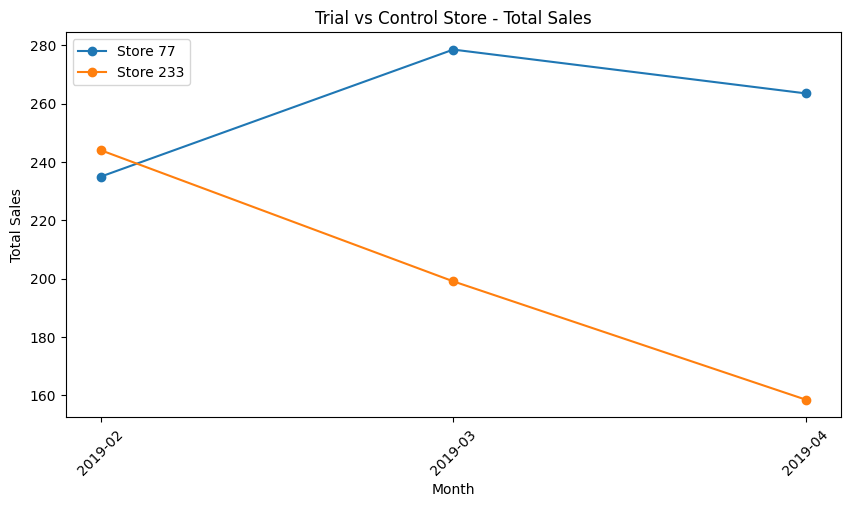

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['TOT_SALES'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Trial vs Control Store - Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()

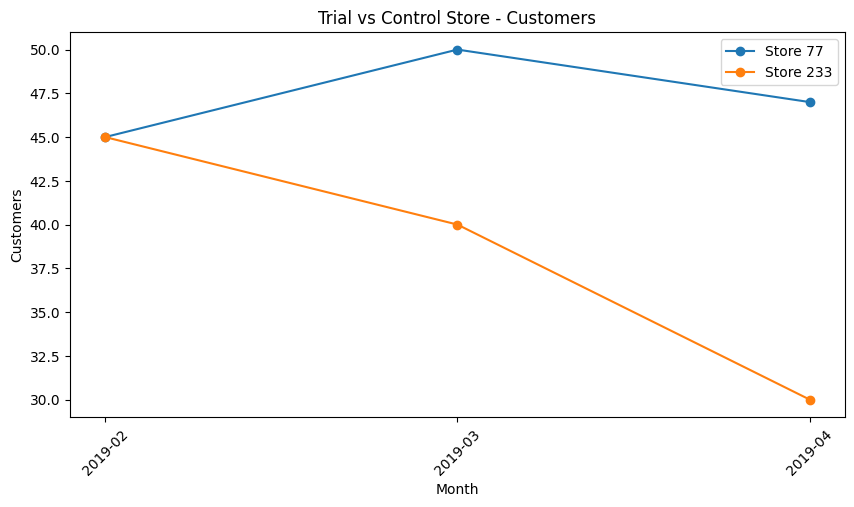

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['CUSTOMERS'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Trial vs Control Store - Customers")
plt.xlabel("Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.legend()
plt.show()

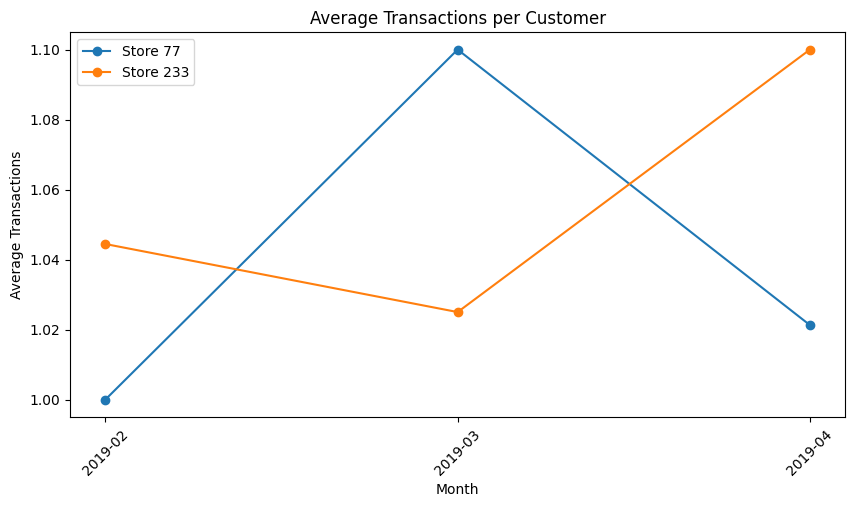

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['AVG_TXN_PER_CUSTOMER'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Average Transactions per Customer")
plt.xlabel("Month")
plt.ylabel("Average Transactions")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

trial_sales = comparison[
    comparison['STORE_NBR'] == trial_store
]['TOT_SALES']

control_sales = comparison[
    comparison['STORE_NBR'] == control_store
]['TOT_SALES']

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.1043553466105163
P-value: 0.12608087519542935


In [ ]:
if p_value < 0.05:
    print("There is a statistically significant difference in sales.")
else:
    print("No statistically significant difference in sales.")

No statistically significant difference in sales.


In [ ]:
trial_store = 86
control_store = 155   # Replace if your control86 output shows a different top store

In [ ]:
comparison = trial_period[
    trial_period['STORE_NBR'].isin([trial_store, control_store])
]

comparison

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER,TOT_SALES
984,86,2019-02,139,107,1.299065,913.2
985,86,2019-03,142,115,1.234783,1026.8
986,86,2019-04,127,105,1.209524,848.2
1800,155,2019-02,127,95,1.336842,891.2
1801,155,2019-03,120,94,1.276596,804.4
1802,155,2019-04,121,99,1.222222,844.6


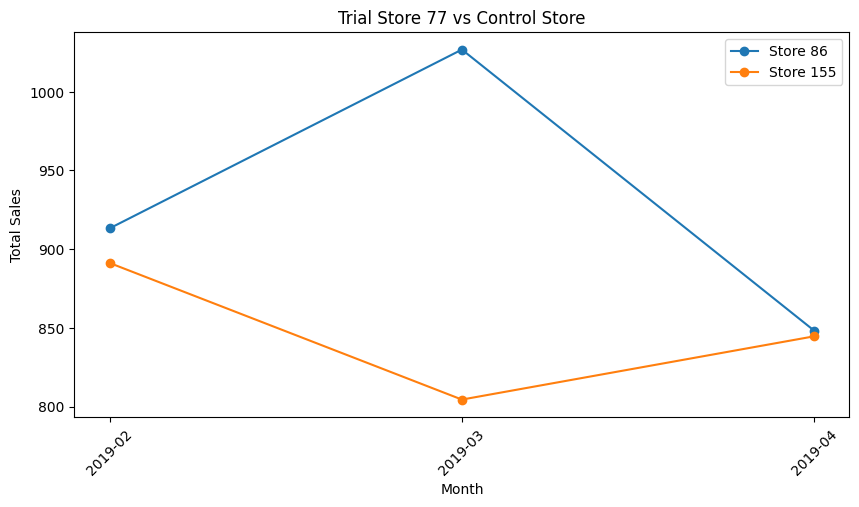

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['TOT_SALES'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Trial Store 77 vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()

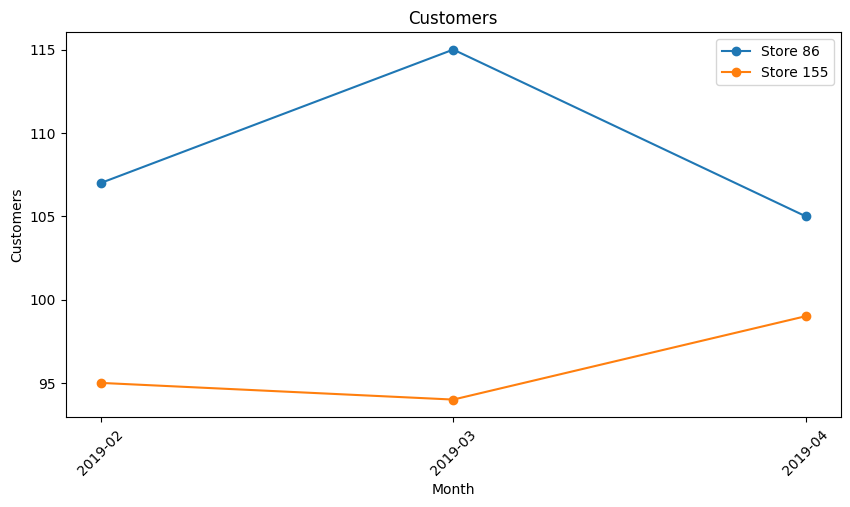

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['CUSTOMERS'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Customers")
plt.xlabel("Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.legend()
plt.show()

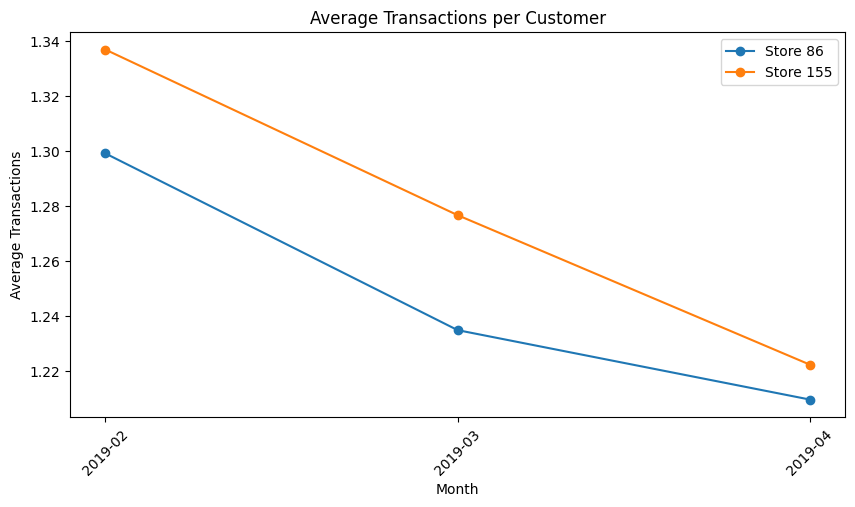

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['AVG_TXN_PER_CUSTOMER'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Average Transactions per Customer")
plt.xlabel("Month")
plt.ylabel("Average Transactions")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

trial_sales = comparison[
    comparison['STORE_NBR'] == trial_store
]['TOT_SALES']

control_sales = comparison[
    comparison['STORE_NBR'] == control_store
]['TOT_SALES']

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.4276735217987158
P-value: 0.25235000204902347


In [ ]:
if p_value < 0.05:
    print("There is a statistically significant difference in sales.")
else:
    print("No statistically significant difference in sales.")

No statistically significant difference in sales.


In [ ]:
trial_store = 88
control_store = 40   # Replace if your control88 output shows a different top store

In [ ]:
comparison = trial_period[
    trial_period['STORE_NBR'].isin([trial_store, control_store])
]

comparison

,STORE_NBR,YEAR_MONTH,TRANSACTIONS,CUSTOMERS,AVG_TXN_PER_CUSTOMER,TOT_SALES
455,40,2019-02,150,125,1.200000,1355.4
456,40,2019-03,141,118,1.194915,1277.6
457,40,2019-04,140,119,1.176471,1249.0
1008,88,2019-02,154,124,1.241935,1370.2
1009,88,2019-03,170,134,1.268657,1477.2
1010,88,2019-04,162,128,1.265625,1439.4


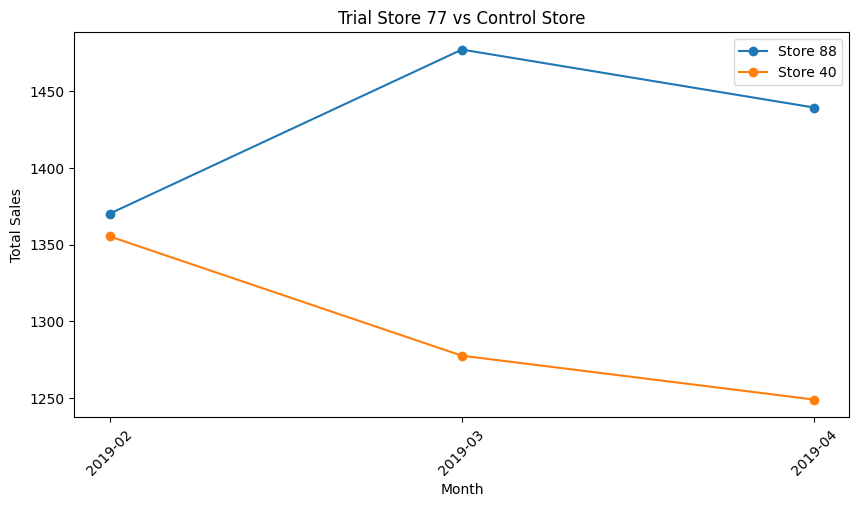

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['TOT_SALES'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Trial Store 77 vs Control Store")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()

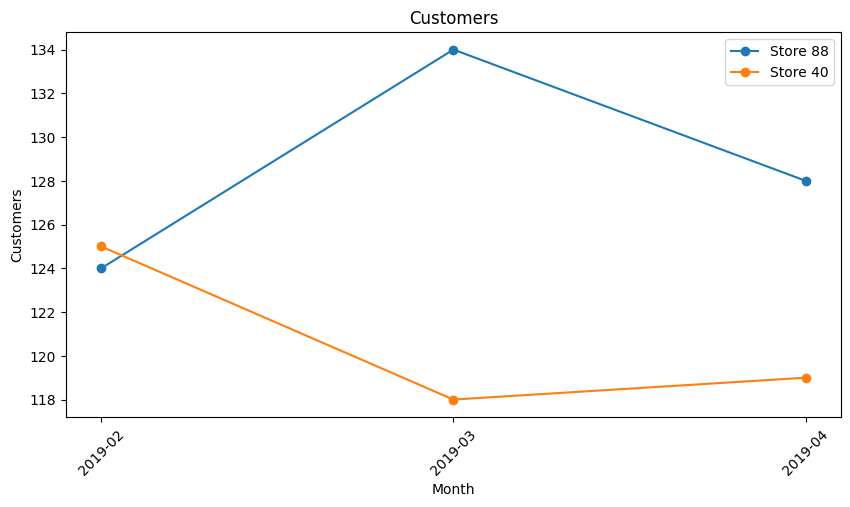

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['CUSTOMERS'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Customers")
plt.xlabel("Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.legend()
plt.show()

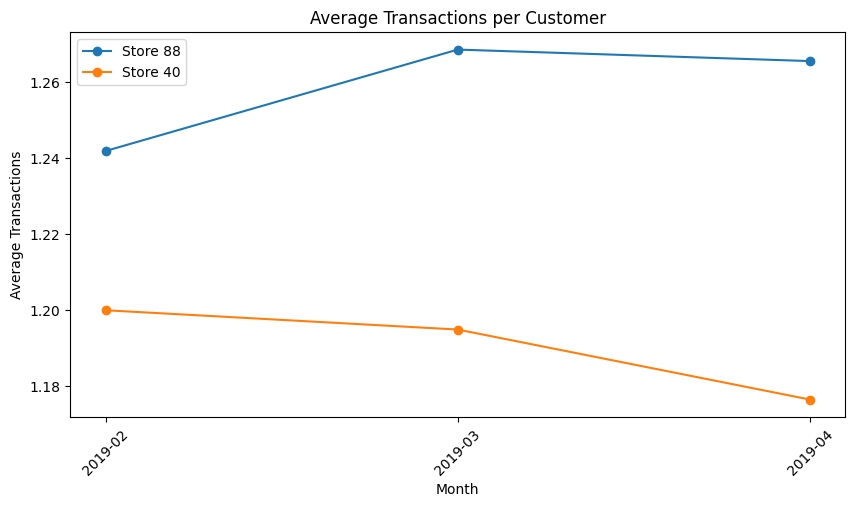

In [ ]:
plt.figure(figsize=(10,5))

for store in [trial_store, control_store]:
    temp = comparison[comparison['STORE_NBR'] == store]

    plt.plot(
        temp['YEAR_MONTH'],
        temp['AVG_TXN_PER_CUSTOMER'],
        marker='o',
        label=f"Store {store}"
    )

plt.title("Average Transactions per Customer")
plt.xlabel("Month")
plt.ylabel("Average Transactions")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

trial_sales = comparison[
    comparison['STORE_NBR'] == trial_store
]['TOT_SALES']

control_sales = comparison[
    comparison['STORE_NBR'] == control_store
]['TOT_SALES']

t_stat, p_value = ttest_ind(
    trial_sales,
    control_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.023159193424273
P-value: 0.039052695976525255


In [ ]:
if p_value < 0.05:
    print("There is a statistically significant difference in sales.")
else:
    print("No statistically significant difference in sales.")

There is a statistically significant difference in sales.


Conclusion

Monthly performance metrics were created for all stores, including total sales, customer count, and average transactions per customer. Suitable control stores were identified for the trial stores using similarity measures based on pre-trial performance. The trial stores were then compared with their respective control stores during the trial period using visual analysis and statistical testing. Based on these results, the impact of the store trials on sales performance and customer purchasing behaviour was evaluated.